In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\08-Linear-Regression-Models\Advertising.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
df['total_spend'] = df.TV + df.radio + df.newspaper
df

,TV,radio,newspaper,sales,total_spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0
...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7
196,94.2,4.9,8.1,9.7,107.2
197,177.0,9.3,6.4,12.8,192.7
198,283.6,42.0,66.2,25.5,391.8


Признак - *total_spend*

Целевая переменная - *sales*

<Axes: xlabel='total_spend', ylabel='sales'>

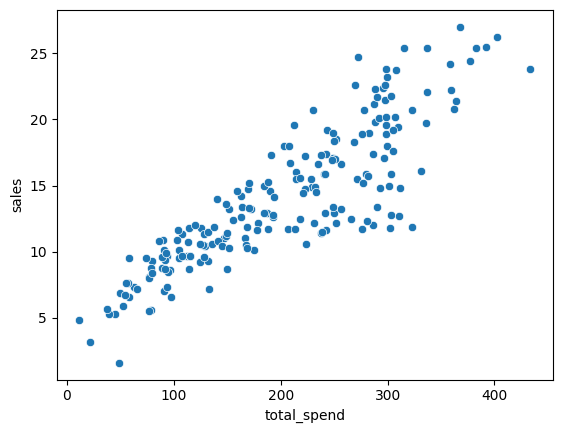

In [7]:
sns.scatterplot(data=df, x='total_spend', y='sales')

<Axes: xlabel='total_spend', ylabel='sales'>

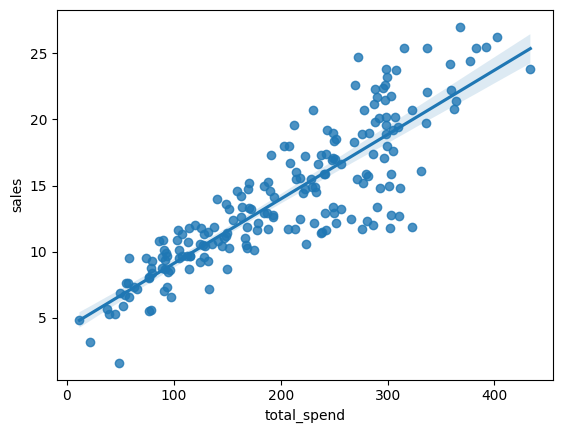

In [8]:
sns.regplot(data=df, x='total_spend', y='sales')

In [9]:
X = df['total_spend']
y = df['sales']

In [10]:
# y = m*x + b
# y = B1*x + B0

np.polyfit() находит коэффиценты линейной регрессии с помощью метода наименьших квадратов

In [11]:
np.polyfit(X,y,deg=1)
#deg=1 - X^1, без Х^2 и тому больше
# получили В1 и В0

array([0.04868788, 4.24302822])

In [12]:
potential_spend = np.linspace(0, 500, 100)

In [13]:
predicted_sales = 0.04868788 * potential_spend + 4.24302822

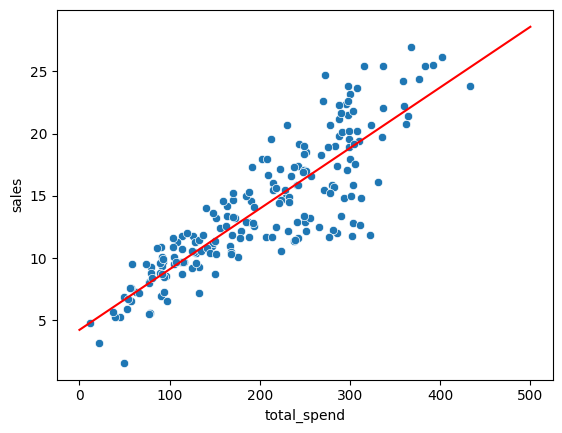

In [15]:
sns.scatterplot(data=df, x='total_spend', y='sales')
plt.plot(potential_spend, predicted_sales, color='red')

In [16]:
spend = 200
predicted_sale = 0.04868788 * spend + 4.24302822
predicted_sale

13.98060422

In [17]:
np.polyfit(X,y,3)

array([ 3.07615033e-07, -1.89392449e-04,  8.20886302e-02,  2.70495053e+00])

y = B3 * x^3 + B2 * x^2 + B1 * x + B0

In [19]:
pot_spend = np.linspace(0, 500, 100)
pred_sales = 3.07615033e-07 * pot_spend ** 3 + \
             -1.89392449e-04 * pot_spend ** 2 + \
             8.20886302e-02 * pot_spend + \
             2.70495053e+00

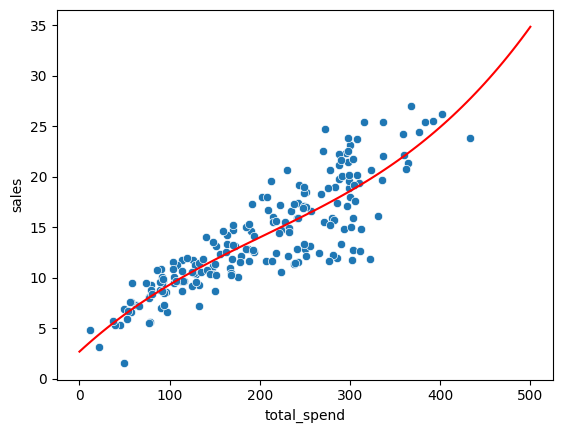

In [20]:
sns.scatterplot(data=df, x='total_spend', y='sales')
plt.plot(pot_spend, pred_sales, color='red')

## **Новый урок про Scikit**

In [27]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\08-Linear-Regression-Models\Advertising.csv")

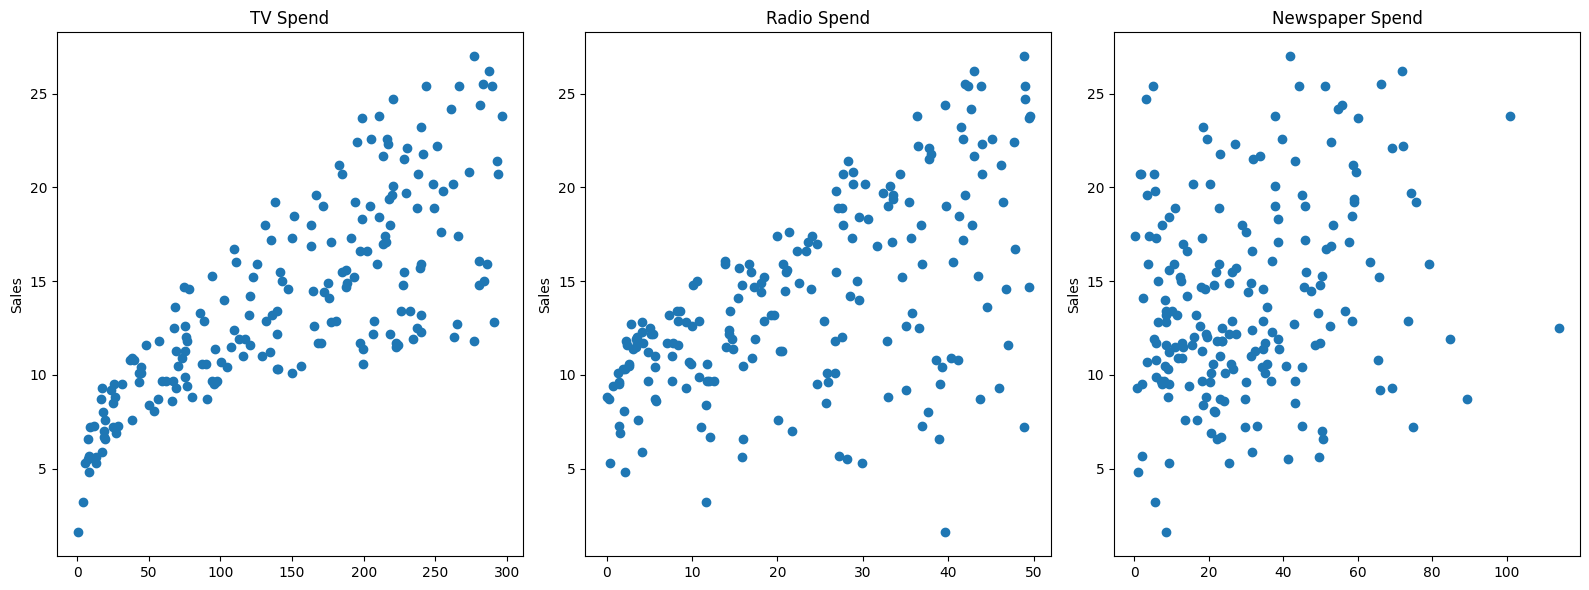

In [28]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout()

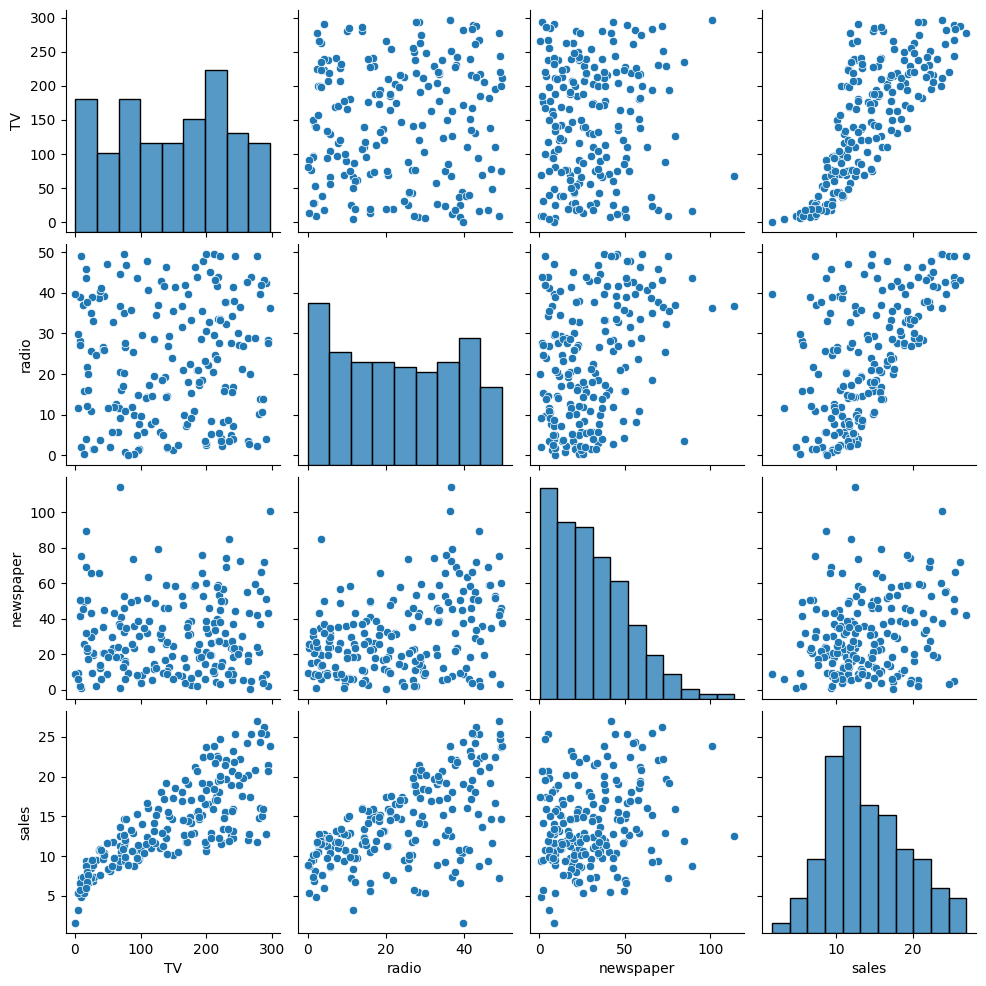

In [29]:
sns.pairplot(df)

In [30]:
X = df.drop('sales', axis=1)

In [31]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [32]:
y = df['sales']

In [33]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [38]:
X_train

,TV,radio,newspaper
85,193.2,18.4,65.7
183,287.6,43.0,71.8
127,80.2,0.0,9.2
53,182.6,46.2,58.7
100,222.4,4.3,49.8
...,...,...,...
63,102.7,29.6,8.4
70,199.1,30.6,38.7
81,239.8,4.1,36.9
11,214.7,24.0,4.0


In [39]:
y_train

85     15.2
183    26.2
127     8.8
53     21.2
100    11.7
       ... 
63     14.0
70     18.3
81     12.3
11     17.4
95     16.9
Name: sales, Length: 140, dtype: float64

In [40]:
type(y_train)

pandas.core.series.Series

In [41]:
from sklearn.linear_model import LinearRegression

In [ ]:
#help(LinearRegression)

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train, y_train)

LinearRegression()

In [46]:
test_predictions = model.predict(X_test)

## **Оценка работы модели**

Метрики для любых задач регрессии
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error

### Метрики

Более подробно про эти метрики мы рассказываем в видео-лекциях!
Для регрессионных задач наиболее часто используются следующие три метрики:

**Средняя абсолютная ошибка - Mean Absolute Error** (MAE) - усредняет абсолютные значения ошибок:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Среднеквадратическая ошибка - Mean Squared Error** (MSE) - усредняет квадраты ошибок:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Среднеквадратическое отклонение - Root Mean Squared Error** (RMSE) - квадратный корень от среднеквадратической ошибки:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Сравнение метрик:

- **MAE** проще всего понять - это просто средняя ошибка.
- **MSE** более популярнее MAE, потому что MSE больше "наказывает" большие ошибки, и обычно это более полезно в прикладных задачах.
- **RMSE** даже ещё более популярна, чем MSE, потому что RMSE измеряется в тех же единицах, что и "y".

Все эти метрики являются **функциями потери (loss functions)**, потому что мы стремимся уменьшить их.

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [48]:
df['sales'].mean()

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

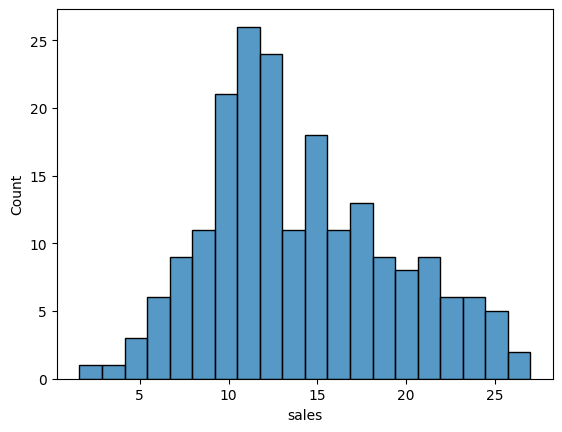

In [51]:
sns.histplot(data=df,x='sales',bins=20)

In [52]:
mean_absolute_error(y_test, test_predictions)

1.213745773614481

In [59]:
#MAE
(mean_absolute_error(y_test, test_predictions)/df['sales'].mean())*100
#средняя ошибка составляет около 8.6% от среднего значения целевой переменной.

np.float64(8.655701719482838)

In [56]:
#MSE
mean_squared_error(y_test, test_predictions)

2.2987166978863782

In [57]:
#RMSE
np.sqrt(mean_squared_error(y_test, test_predictions))

np.float64(1.516151937599388)

In [60]:
(np.sqrt(mean_squared_error(y_test, test_predictions))/df['sales'].mean())*100

np.float64(10.812279818858176)

MAE MSE не сильно отличаются друг от друга. Значит, что нет сильно отклоняющихся точек. Если бы MAE было хорошим, а MSE - слишком уж большим, \
то тогда можно было делать вывод, что есть какие-то точки, для которых модель очень сильно отличается

## **Остатки (residuals)**

Остатки, или же ошибки

$(Actual - Predicted)$

$(y-ŷ)$

In [62]:
test_residuals = y_test - test_predictions

In [64]:
#test_residuals

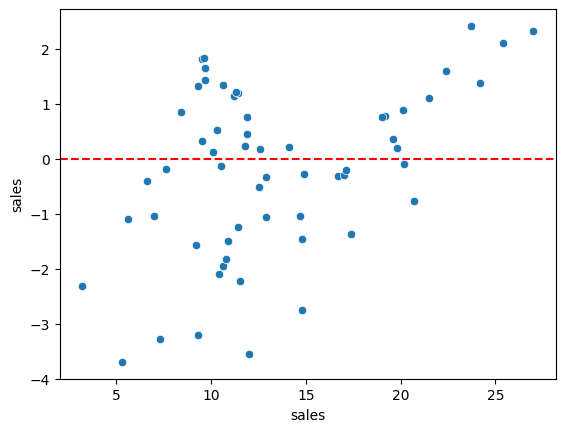

In [66]:
sns.scatterplot(x=y_test, y=test_residuals)
plt.axhline(y=0, color='red', ls='--')

Какой-то зависимости между точками нет, разбросаны хаотично --> все кайф

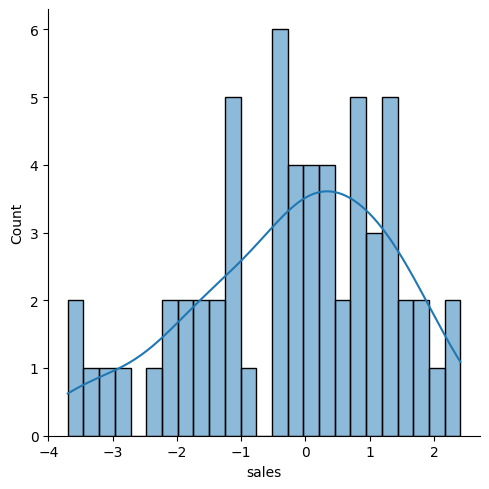

In [67]:
sns.displot(test_residuals, bins=25, kde=True)

In [68]:
import scipy as sp

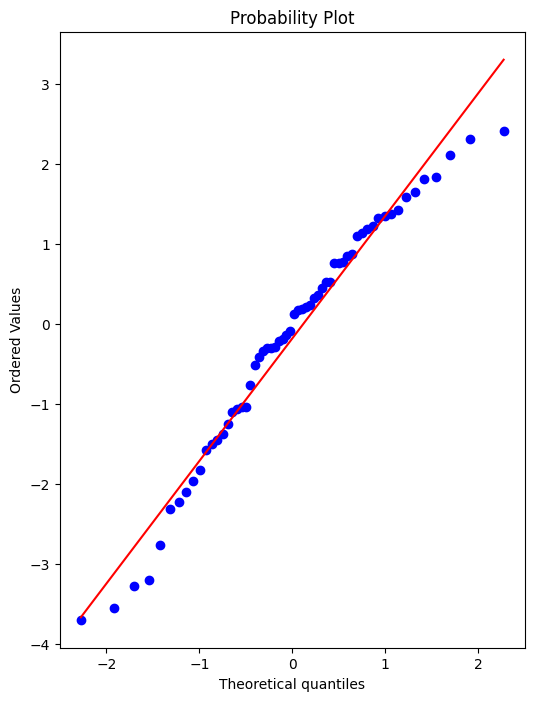

In [69]:
# Создаём объект figure и оси для рисования графика
fig, ax = plt.subplots(figsize=(6,8),dpi=100)

# probplot возвращает значения, которые можно использовать при необходимости
# мы хотим просто нарисовать график, поэтому присваиваем эти значения переменной _
_ = sp.stats.probplot(test_residuals,plot=ax)

Если мы приняли решение о том, что созданная модель нам подходит, то следующий шаг - обучить новую модель на всех данных

In [70]:
final_model = LinearRegression()

In [71]:
final_model.fit(X,y)
#модель будет более точной, т.к. она обучается на большем кол-ве данных

LinearRegression()

Теперь сохраним модель в файл. Но сначала посмотрим на коэффиценты

In [72]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [78]:
coeff_df = pd.DataFrame(data=final_model.coef_, index=X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
TV,0.045765
radio,0.188530
newspaper,-0.001037


$y = b0 + b1 * TV + b2 * radio + b3 * newspaper$

b0 хранится в .intercept_

b1, b2, b3 хранятся в .coef_ - по порядку признаков (features)

3ий коэффицент почти равен 0. \
Если бы он был равен 0, то модель бы считала, 
что вне зависимости от затрат на газеты, они бы не влияли на продажи
Коэфф-т отрицательный, что значит, что затрата на газеты даже немного снижает продажи

In [73]:
y_hat = final_model.predict(X)


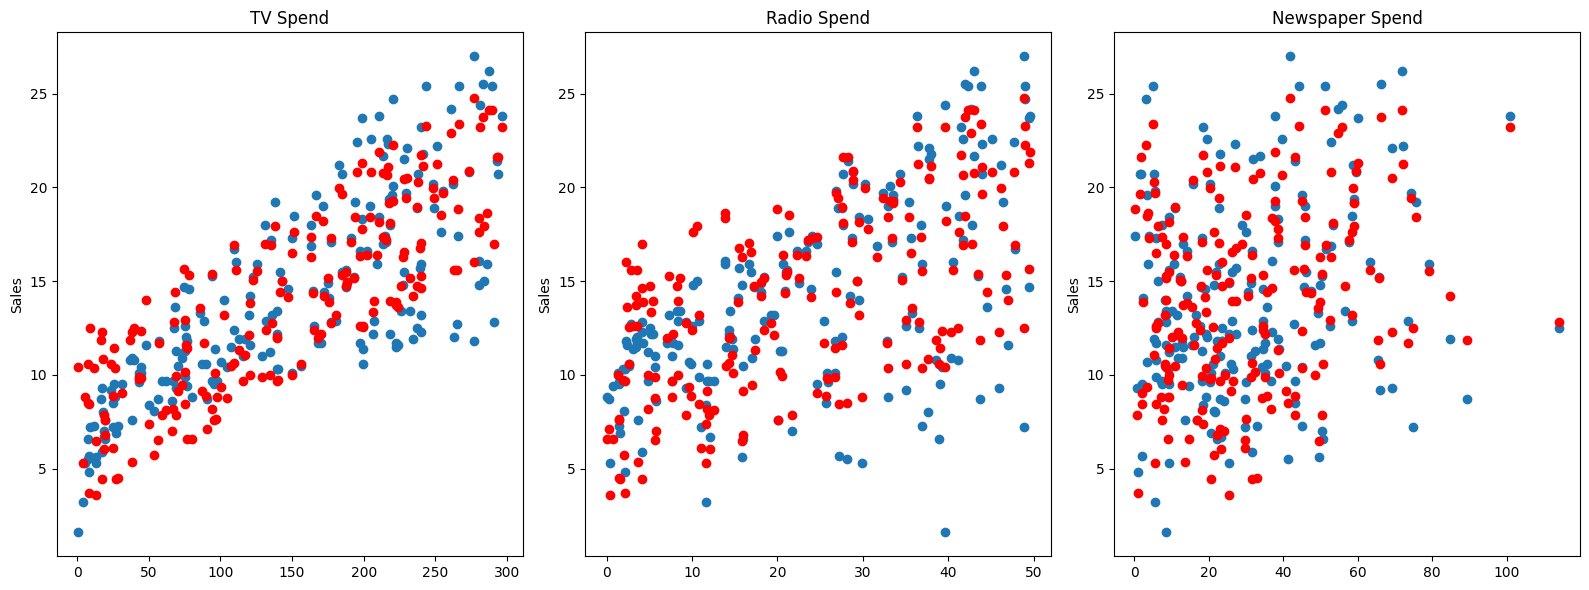

In [79]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o',color='red')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o',color='red')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'o',color='red')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout();

In [75]:
residuals = y_hat - y

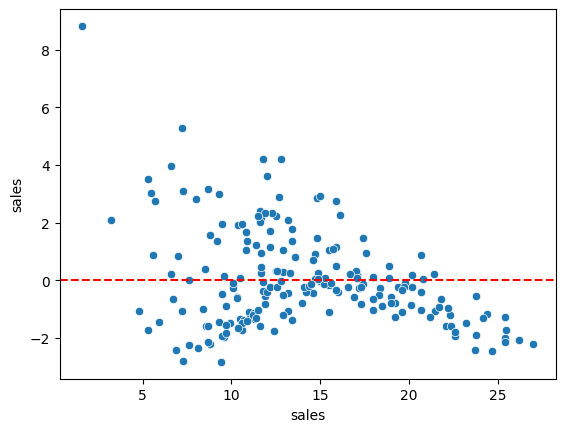

In [76]:
sns.scatterplot(x=y,y=residuals)
plt.axhline(y=0, c='r',linestyle='--')

#### **Сохранение и загрузка модели. Введение в эксплуатацию**

In [82]:
from joblib import dump, load

In [83]:
dump(final_model, 'final_sales_model.joblib')

['final_sales_model.joblib']

In [84]:
loaded_model = load('final_sales_model.joblib')

In [85]:
loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [86]:
X.shape

(200, 3)

In [87]:
# 149 TV, 22 radio, 12 newspaper
# Sales ?
campaign = [[149, 22, 12]]

In [88]:
loaded_model.predict(campaign)

C:\Users\Надежда\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032])

# **Полиномиальная регрессия**

In [89]:
X = df.drop('sales', axis=1)
y = df['sales']

In [90]:
from sklearn.preprocessing import PolynomialFeatures

In [91]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [ ]:
polynomial_converter.fit()